In [32]:
import pandas as pd

triazine_df = pd.read_csv("../results/pro_cleaned_triazines.csv")

In [33]:
'''Let's find molecules having donar atoms at pos1, pos2 and pos3. '5,6-dimethyl-1,2,4-triazine-3-pos1-pos2-pos3'''

from rdkit import Chem

# Donor at position 1 (directly on C3)
pos1 = Chem.MolFromSmarts('c1(C)nnc(nc1C)~[#7,#8,#16]')

# Donor at position 2 (1 carbon away)
pos2 = Chem.MolFromSmarts('c1(C)nnc(nc1C)~[#6]~[#7,#8,#16]')

# Donor at position 3 (2 carbons away)
pos3 = Chem.MolFromSmarts('c1(C)nnc(nc1C)~[#6]~[#6]~[#7,#8,#16]')



triazine_df['has_donor_pos1'] = triazine_df['SMILES'].apply(
    lambda smi: Chem.MolFromSmiles(smi).HasSubstructMatch(pos1)
    if Chem.MolFromSmiles(smi) else False
)

triazine_df['has_donor_pos2'] = triazine_df['SMILES'].apply(
    lambda smi: Chem.MolFromSmiles(smi).HasSubstructMatch(pos2)
    if Chem.MolFromSmiles(smi) else False
)

triazine_df['has_donor_pos3'] = triazine_df['SMILES'].apply(
    lambda smi: Chem.MolFromSmiles(smi).HasSubstructMatch(pos3)
    if Chem.MolFromSmiles(smi) else False
)

donor_df = triazine_df[
    (triazine_df['has_donor_pos1']) |
    (triazine_df['has_donor_pos2']) |
    (triazine_df['has_donor_pos3'])
].reset_index(drop=True)

print(f"Before: {len(triazine_df)}")
print(f"After:  {len(donor_df)}")
print(f"Removed: {len(triazine_df) - len(donor_df)}")
print(f"Pos1 donors: {triazine_df['has_donor_pos1'].sum()}")
print(f"Pos2 donors: {triazine_df['has_donor_pos2'].sum()}")
print(f"Pos3 donors: {triazine_df['has_donor_pos3'].sum()}")

Before: 4951
After:  3263
Removed: 1688
Pos1 donors: 0
Pos2 donors: 2119
Pos3 donors: 1526


In [34]:
donor_df.to_csv('../results/donor_triazine.csv', index=False) 

In [35]:
both = triazine_df[
    (triazine_df['has_donor_pos2']) &
    (triazine_df['has_donor_pos3'])
]
print(f"Molecules with donors at BOTH pos2 and pos3: {len(both)}")

Molecules with donors at BOTH pos2 and pos3: 382


In [36]:
'''keeping molecules, that are having donor atoms at any one position'''

valid_df = triazine_df[
    (triazine_df['has_donor_pos2']) |
    (triazine_df['has_donor_pos3'])
].reset_index(drop=True)

print(f"Valid chelating candidates: {len(valid_df)}")

Valid chelating candidates: 3263


In [37]:
'''Obviously, Bis-triazine will be the top candidate for metal sensing in this library. So, let's find in both Bis- and Mono-'''

bis_df = valid_df[valid_df['n_triazine_rings'] == 2].reset_index(drop=True)

mono_df = valid_df[valid_df['n_triazine_rings'] == 1].reset_index(drop=True)

print(f"Bis-triazines:  {len(bis_df)}")
print(f"Mono-triazines: {len(mono_df)}")

Bis-triazines:  27
Mono-triazines: 3236


In [38]:
'''segregating molecules donor atoms position, either it is at pos2 or pos3 or both'''

only_pos2 = mono_df[
    (mono_df['has_donor_pos2']) & (~mono_df['has_donor_pos3'])
]

only_pos3 = mono_df[
    (mono_df['has_donor_pos3']) & (~mono_df['has_donor_pos2'])
] 

both_pos2_pos3 = mono_df[
    (mono_df['has_donor_pos2']) & (mono_df['has_donor_pos3'])
] 

print(f"Only pos2:      {len(only_pos2)}")
print(f"Only pos3:      {len(only_pos3)}")
print(f"Both pos2+pos3: {len(both_pos2_pos3)}")
print(f"Total:          {len(only_pos2) + len(only_pos3) + len(both_pos2_pos3)}")


Only pos2:      1729
Only pos3:      1132
Both pos2+pos3: 375
Total:          3236


In [39]:
'''Bridged and non-bridged compounds can have different geometry, even if their donor position matches. So, let's catagorize it.'''

pos2_bridged    = Chem.MolFromSmarts('c1(C)nnc(nc1C)~[#6;X4;!R]~[#7,#8,#16]')
a = Chem.MolFromSmarts('c1(C)nnc(nc1C)~[#6;X3]~[#7,#8,#16]')
b = Chem.MolFromSmarts('c1(C)nnc(nc1C)~[#6;X4;R]~[#7,#8,#16]')
pos3_bridged    = Chem.MolFromSmarts('c1(C)nnc(nc1C)~[#6;X4;!R]~[#6]~[#7,#8,#16]')
c = Chem.MolFromSmarts('c1(C)nnc(nc1C)~[#6;X3]~[#6]~[#7,#8,#16]')
d = Chem.MolFromSmarts('c1(C)nnc(nc1C)~[#6;X4;R]~[#6]~[#7,#8,#16]')


mono_df['has_pos2_bridged'] = mono_df['SMILES'].apply(
    lambda smi: Chem.MolFromSmiles(smi).HasSubstructMatch(pos2_bridged)
    if Chem.MolFromSmiles(smi) else False
)

mono_df['has_pos3_bridged'] = mono_df['SMILES'].apply(
    lambda smi: Chem.MolFromSmiles(smi).HasSubstructMatch(pos3_bridged)
    if Chem.MolFromSmiles(smi) else False
)

def check_bridged(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return False
    return mol.HasSubstructMatch(a) or mol.HasSubstructMatch(b)

mono_df['has_pos2_notbridged'] = mono_df['SMILES'].apply(check_bridged)

def check_bridged(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return False
    return mol.HasSubstructMatch(c) or mol.HasSubstructMatch(d)

mono_df['has_pos3_notbridged'] = mono_df['SMILES'].apply(check_bridged)

bridge_df = mono_df[
    (mono_df['has_pos2_bridged']) |
    (mono_df['has_pos2_notbridged']) |
    (mono_df['has_pos3_bridged']) |
    (mono_df['has_pos3_notbridged'])
].reset_index(drop=True)

print(f"Pos2 bridged: {mono_df['has_pos2_bridged'].sum()}")
print(f"Pos2 notbridged: {mono_df['has_pos2_notbridged'].sum()}")
print(f"Pos3 bridged: {mono_df['has_pos3_bridged'].sum()}")
print(f"Pos3 notbridged: {mono_df['has_pos3_notbridged'].sum()}")
len(bridge_df)

Pos2 bridged: 793
Pos2 notbridged: 1311
Pos3 bridged: 240
Pos3 notbridged: 1267


3236

In [40]:
'''narrowing further to know.. which position has how many bridged/non-bridged compounds'''

only_pos2_bridged = mono_df[
    (mono_df['has_pos2_bridged']) & 
    (~mono_df['has_pos3_bridged'])&
    (~mono_df['has_pos3_notbridged'])
]

only_pos2_notbridged = mono_df[
    (mono_df['has_pos2_notbridged']) & 
    (~mono_df['has_pos3_notbridged'])&
    (~mono_df['has_pos3_bridged'])
]  
only_pos3_bridged    = mono_df[
    (mono_df['has_pos3_bridged']) & 
    (~mono_df['has_pos2_bridged'])&
    (~mono_df['has_pos2_notbridged'])
]  
only_pos3_notbridged = mono_df[
    (mono_df['has_pos3_notbridged']) & 
    (~mono_df['has_pos2_bridged']) & 
    (~mono_df['has_pos2_notbridged'])
]  

both_bridged = mono_df[
    (mono_df['has_pos2_bridged'])&
    (mono_df['has_pos3_bridged'])
]

both_notbridged = mono_df[
    (mono_df['has_pos2_notbridged'])&
    (mono_df['has_pos3_notbridged'])
]

print(f"Only pos2 bridged:    {len(only_pos2_bridged)}")
print(f"Only pos2 notbridged: {len(only_pos2_notbridged)}")
print(f"Only pos3 bridged:    {len(only_pos3_bridged)}")
print(f"Only pos3 notbridged: {len(only_pos3_notbridged)}")
print(f"Both Bridged:         {len(both_bridged)}")
print(f"Both Not Bridged:     {len(both_notbridged)}")
print(f"Total:                {len(only_pos2_bridged)+len(only_pos2_notbridged)+len(only_pos3_bridged)+len(only_pos3_notbridged)+len(both_bridged)+len(both_notbridged)}")

Only pos2 bridged:    781
Only pos2 notbridged: 948
Only pos3 bridged:    228
Only pos3 notbridged: 904
Both Bridged:         12
Both Not Bridged:     363
Total:                3236


In [41]:
'''Let's store this data in a separate dataframe'''

base_cols = ['Triazine_ID', 'SMILES', 'MolWt', 'LogP', 'TPSA', 'HBD', 'HBA',
             'RotatableBonds', 'AromaticRings', 'n_triazine_rings', 'mol']

groups = {
    'only_pos2_bridged': only_pos2_bridged,
    'only_pos2_notbridged': only_pos2_notbridged,
    'only_pos3_bridged': only_pos3_bridged,
    'only_pos3_notbridged': only_pos3_notbridged,
    'both_bridged': both_bridged,
    'both_notbridged': both_notbridged,
}

pieces = []
for name, df in groups.items():
    tmp = df[base_cols].copy()
    tmp['Donor_pos'] = name
    pieces.append(tmp)

geometry_df = pd.concat(pieces, ignore_index=True)

print(geometry_df['Donor_pos'].value_counts())
print("Total:", len(geometry_df)) 

Donor_pos
only_pos2_notbridged    948
only_pos3_notbridged    904
only_pos2_bridged       781
both_notbridged         363
only_pos3_bridged       228
both_bridged             12
Name: count, dtype: int64
Total: 3236


In [42]:
'''Knowing, whether the donor is in the ring or not can help us know the rigidity of the molecule upon chelation'''

pos2_inring    = Chem.MolFromSmarts('c1(C)nnc(nc1C)~[#6]~[#7,#8,#16;R]')
pos2_notinring = Chem.MolFromSmarts('c1(C)nnc(nc1C)~[#6]~[#7,#8,#16;!R]')
pos3_inring    = Chem.MolFromSmarts('c1(C)nnc(nc1C)~[#6]~[#6]~[#7,#8,#16;R]')
pos3_notinring = Chem.MolFromSmarts('c1(C)nnc(nc1C)~[#6]~[#6]~[#7,#8,#16;!R]')


mono_df['pos2_inring'] = mono_df['SMILES'].apply(
    lambda smi: Chem.MolFromSmiles(smi).HasSubstructMatch(pos2_inring)
    if Chem.MolFromSmiles(smi) else False
)

mono_df['pos2_notinring'] = mono_df['SMILES'].apply(
    lambda smi: Chem.MolFromSmiles(smi).HasSubstructMatch(pos2_notinring)
    if Chem.MolFromSmiles(smi) else False
)

mono_df['pos3_inring'] = mono_df['SMILES'].apply(
    lambda smi: Chem.MolFromSmiles(smi).HasSubstructMatch(pos3_inring)
    if Chem.MolFromSmiles(smi) else False
)

mono_df['pos3_notinring'] = mono_df['SMILES'].apply(
    lambda smi: Chem.MolFromSmiles(smi).HasSubstructMatch(pos3_notinring)
    if Chem.MolFromSmiles(smi) else False
)


def assign_ring_status(row):
    p2in  = row['pos2_inring']
    p2out = row['pos2_notinring']
    p3in  = row['pos3_inring']
    p3out = row['pos3_notinring']
    
    # Build descriptive label showing ALL donor information
    parts = []
    
    if p2in and p2out: parts.append('pos2_both')
    elif p2in:         parts.append('pos2_inring')
    elif p2out:        parts.append('pos2_notinring')
    
    if p3in and p3out: parts.append('pos3_both')
    elif p3in:         parts.append('pos3_inring')
    elif p3out:        parts.append('pos3_notinring')
    
    if parts: return '+'.join(parts)
    return 'no_donor'

mono_df['ring_status'] = mono_df.apply(assign_ring_status, axis=1)
print(mono_df['ring_status'].value_counts())

ring_status
pos2_inring                      1001
pos2_notinring                    727
pos3_inring                       572
pos3_notinring                    380
pos2_inring+pos3_inring           248
pos3_both                         180
pos2_inring+pos3_notinring         80
pos2_inring+pos3_both              28
pos2_notinring+pos3_notinring      13
pos2_notinring+pos3_inring          5
pos2_both+pos3_inring               1
pos2_both                           1
Name: count, dtype: int64


In [43]:
'''clean dataset for metal sensing'''

fina_df = pd.merge(geometry_df, mono_df)

final_df = fina_df.drop(columns=[ 'Has_Hydrazine', 'Has_Acyl_Hydrazide'])


final_df.head()

,Triazine_ID,SMILES,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,AromaticRings,n_triazine_rings,...,has_donor_pos3,has_pos2_bridged,has_pos3_bridged,has_pos2_notbridged,has_pos3_notbridged,pos2_inring,pos2_notinring,pos3_inring,pos3_notinring,ring_status
0,TRZ00008,Cc1nnc(CN2C(=O)CN=C(c3ccccc3)c3cc(Br)ccc32)nc1C,436.31,3.64,71.34,0,5,3,3,1,...,False,True,False,False,False,True,False,False,False,pos2_inring
1,TRZ00029,Cc1nnc(C(O)c2ccccc2)nc1C,215.26,1.57,58.90,1,4,2,2,1,...,False,True,False,False,False,False,True,False,False,pos2_notinring
2,TRZ00030,Cc1nnc(C(O)(c2ccccc2)c2ccccc2)nc1C,291.35,2.77,58.90,1,4,3,3,1,...,False,True,False,False,False,False,True,False,False,pos2_notinring
3,TRZ00032,Cc1nnc(COc2cccc3ccccc23)nc1C,265.32,3.22,47.90,0,4,3,3,1,...,False,True,False,False,False,False,True,False,False,pos2_notinring
4,TRZ00036,Cc1nnc(Cn2cnc3ccccc32)nc1C,239.28,1.89,56.49,0,4,2,3,1,...,False,True,False,False,False,True,False,False,False,pos2_inring


In [44]:
'''removing invalid combos, eg; donor atom at pos3 only and the compound is not bridged molecules can't act as bidentate ligand as their geometry won't allow it.'''

# Invalid combinations using Donor_pos + ring_status together
invalid1 = (final_df['Donor_pos'] == 'only_pos3_notbridged') & (final_df['pos3_inring'])
invalid2 = (final_df['Donor_pos'] == 'only_pos2_bridged') & (final_df['pos2_inring'])

valid_final_df = final_df[
    ~invalid1 & ~invalid2
].reset_index(drop=True)

print(f"Before: {len(final_df)}")
print(f"After:  {len(valid_final_df)}")
print(f"Removed: {len(final_df) - len(valid_final_df)}")

Before: 3236
After:  2417
Removed: 819


In [45]:
'''molecules having more no. of rings with donor atoms may have higher spectroscopic properties and also can help to find multidentate ligands'''

from rdkit.Chem import rdMolDescriptors

valid_final_df['total_rings'] = valid_final_df['SMILES'].apply(
    lambda smi: rdMolDescriptors.CalcNumRings(Chem.MolFromSmiles(smi))
    if Chem.MolFromSmiles(smi) else 0
)

print(valid_final_df['total_rings'].value_counts().sort_index())

total_rings
2    828
3    925
4    530
5    112
6     19
7      2
8      1
Name: count, dtype: int64


In [46]:
'''Let's remove non-aromatic rings, As aromatic rings can give distinct fluorescene change upon metal chelation'''

fully_aromatic_df = valid_final_df[
    valid_final_df['total_rings'] == valid_final_df['AromaticRings']
].reset_index(drop=True)

print(f"Fully aromatic: {len(fully_aromatic_df)}")
print(fully_aromatic_df['total_rings'].value_counts().sort_index())

Fully aromatic: 1932
total_rings
2    828
3    719
4    354
5     29
6      2
Name: count, dtype: int64


In [47]:
'''removed 5,6 ring molecules after inspected manually...their geometry is not efficient for metal sensing'''

aromati_filtered_df = fully_aromatic_df[
    fully_aromatic_df['total_rings'] <= 4
].reset_index(drop=True)

print(f"Before: {len(fully_aromatic_df)}")
print(f"After:  {len(aromati_filtered_df)}")

Before: 1932
After:  1901


In [48]:
aromati_filtered_df['extra_donors'] = aromati_filtered_df['HBA'] - 3

print(aromati_filtered_df['extra_donors'].value_counts().sort_index())

extra_donors
0     32
1    655
2    627
3    380
4    162
5     42
6      3
Name: count, dtype: int64


In [49]:
'''remove molecules that are having only one donor atoms apart from triazne N's.'''

aromatic_filtered_df = aromati_filtered_df[
    aromati_filtered_df['extra_donors'] >= 2
].reset_index(drop=True)

print(f"After:  {len(aromatic_filtered_df)}")
print(aromatic_filtered_df['extra_donors'].value_counts().sort_index())

After:  1214
extra_donors
2    627
3    380
4    162
5     42
6      3
Name: count, dtype: int64


In [50]:
'''removing molecules that are having plain phenyl rings, rings with donor atoms can be more efficient for metal binding'''

plain_phenyl = Chem.MolFromSmarts('c1ccccc1')

aromatic_filtered_df['has_plain_phenyl'] = aromatic_filtered_df['SMILES'].apply(
    lambda smi: Chem.MolFromSmiles(smi).HasSubstructMatch(pos3_notinring)
    if Chem.MolFromSmiles(smi) else False
)

no_phenyl_df = aromatic_filtered_df[
    ~aromatic_filtered_df['has_plain_phenyl']
].reset_index(drop=True)

print(f"Before: {len(aromatic_filtered_df)}")
print(f"After:  {len(no_phenyl_df)}")

Before: 1214
After:  940


In [51]:

direct = no_phenyl_df[
    (no_phenyl_df['total_rings'] >= 3) &
    (no_phenyl_df['pos2_inring']) &
    (no_phenyl_df['extra_donors'] >= 2)
]

bridged = no_phenyl_df[
    (no_phenyl_df['total_rings'] >= 3) &
    (no_phenyl_df['pos3_inring']) &
    (~no_phenyl_df['pos2_inring']) &
    (no_phenyl_df['extra_donors'] >= 2)
]

print(f"Direct connection: {len(direct)}")
print(f"CH2 bridged:       {len(bridged)}")

Direct connection: 407
CH2 bridged:       52


In [52]:
'''Let's find molecules, that are having potential to be tridentate ligand'''

pattern = Chem.MolFromSmarts('c1(C)nnc(nc1C)~[#6]~[#7,#8,#16]~[#6]~[#6]~[#7,#8,#16]')

no_phenyl_df['tridentate'] = no_phenyl_df['SMILES'].apply(
    lambda smi: Chem.MolFromSmiles(smi).HasSubstructMatch(pattern) if Chem.MolFromSmiles(smi) else False
)

new_df = no_phenyl_df[no_phenyl_df['tridentate'] == True].reset_index(drop=True)

print(f"Total: {no_phenyl_df['tridentate'].sum()}")

Total: 183


In [53]:
'''Through this process, few molecules have been found that can be potential tridentate ligand'''

reference_ids = [
    'TRZ02396', 'TRZ02390', 'TRZ00399',
    'TRZ00375', 'TRZ05498', 'TRZ01544',
    'TRZ02392', 'TRZ00628', 'TRZ00117', 
    'TRZ01080', 'TRZ00112', 'TRZ05734'
]

reference_df = valid_final_df[
    valid_final_df['Triazine_ID'].isin(reference_ids)
].reset_index(drop=True)

print(f"Reference compounds: {len(reference_df)}")

Reference compounds: 12


In [54]:
'''let's generate fingerprints of the reference and our libary molecules'''

from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

ref_fps = [morgan_gen.GetFingerprint(Chem.MolFromSmiles(smi)) 
           for smi in reference_df['SMILES']]

lib_fps = [morgan_gen.GetFingerprint(Chem.MolFromSmiles(smi)) 
           for smi in new_df['SMILES']]

print(f"Reference fingerprints: {len(ref_fps)}")
print(f"Library fingerprints:   {len(lib_fps)}")

Reference fingerprints: 12
Library fingerprints:   183


In [55]:
'''Using TanimotoSimilarity, we can find molecules that are similar to reference compounds'''

from rdkit import DataStructs

def max_similarity_to_references(lib_fp):
    similarities = DataStructs.BulkTanimotoSimilarity(lib_fp, ref_fps)
    return max(similarities)

new_df['max_similarity'] = [
    max_similarity_to_references(fp) for fp in lib_fps
]

print(new_df['max_similarity'].describe())
print(f"\nDistribution:")
print(f"Similarity > 0.8: {(new_df['max_similarity'] > 0.8).sum()}")
print(f"Similarity > 0.6: {(new_df['max_similarity'] > 0.6).sum()}")
print(f"Similarity > 0.4: {(new_df['max_similarity'] > 0.4).sum()}")

count    183.000000
mean       0.427516
std        0.202774
min        0.179775
25%        0.285714
50%        0.365385
75%        0.500000
max        1.000000
Name: max_similarity, dtype: float64

Distribution:
Similarity > 0.8: 12
Similarity > 0.6: 28
Similarity > 0.4: 74


Similar molecules: 28


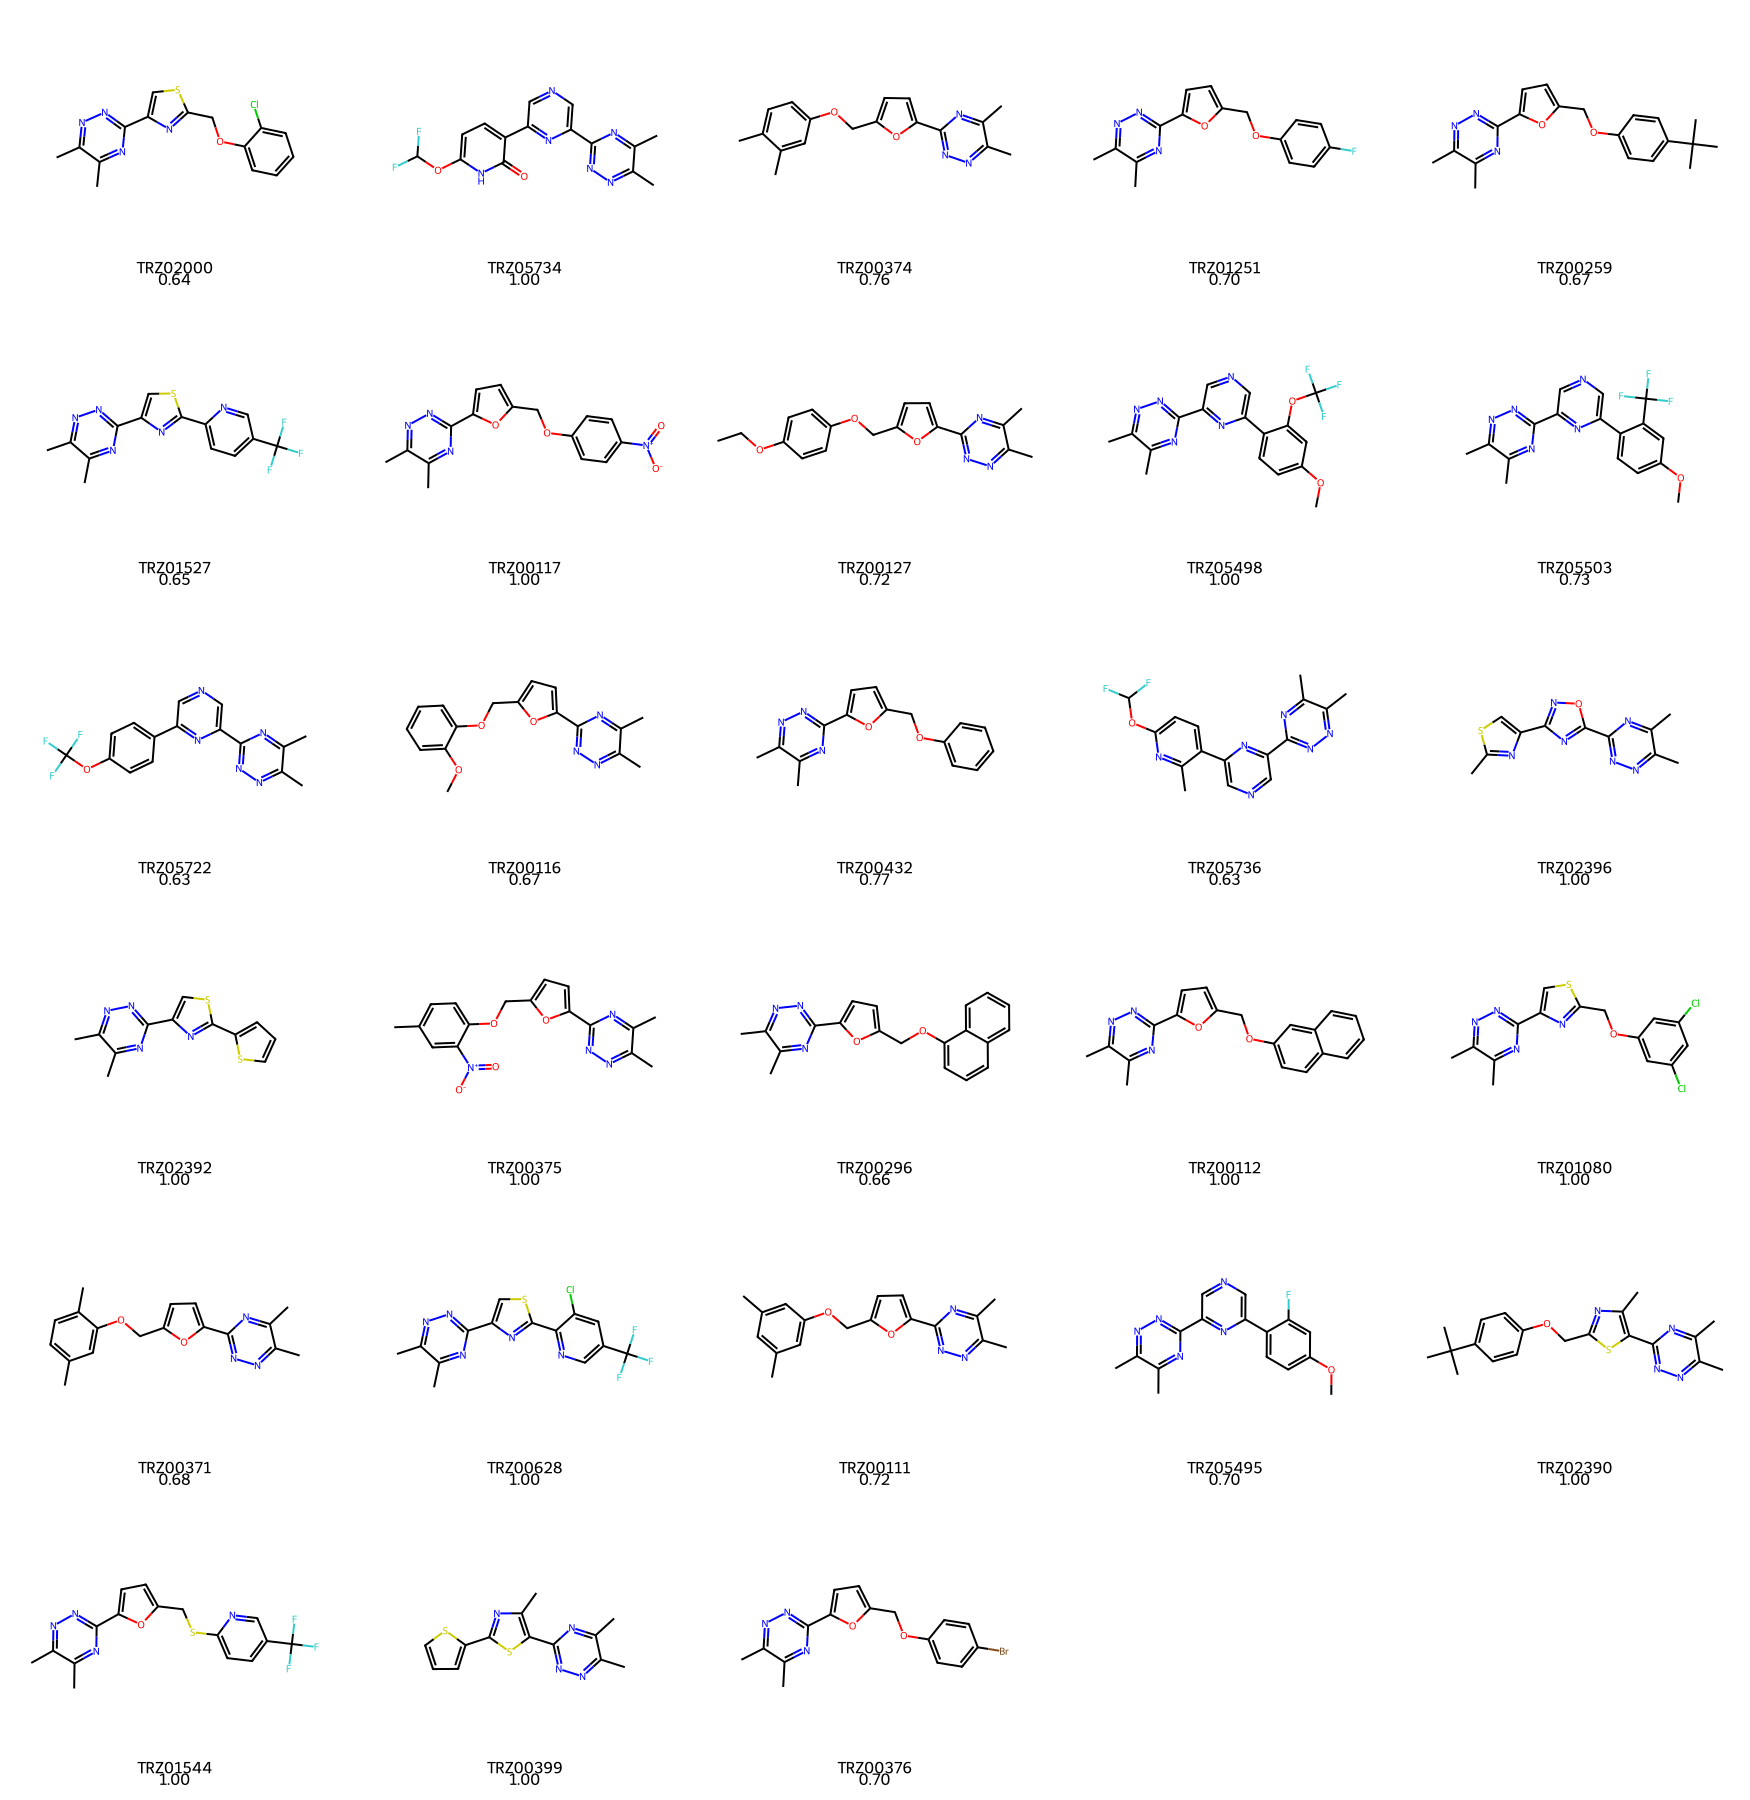

In [56]:
'''visualize molecules that are having maximum similarity with our references'''
from rdkit.Chem import Draw

similar_df = new_df[
    (new_df['max_similarity'] >= 0.6) &
    (new_df['max_similarity'] <= 1.0)
].reset_index(drop=True)

print(f"Similar molecules: {len(similar_df)}")

sample = similar_df.sample(min(30, len(similar_df)))
mols = [Chem.MolFromSmiles(s) for s in sample['SMILES']]
legends = [f"{tid}\n{sim:.2f}" for tid, sim in 
           zip(sample['Triazine_ID'], sample['max_similarity'])]

img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(350,300), legends=legends)
display(img)

In [57]:
bis_ids = [
    'TRZ00686', 'TRZ00727', 'TRZ01194', 'TRZ01492', 'TRZ02619', 'TRZ02802'
]

top_bis_df = bis_df[
    bis_df['Triazine_ID'].isin(bis_ids)
].reset_index(drop=True)

len(top_bis_df)

6

In [58]:
mono_ids = [
    'TRZ05503', 'TRZ05722', 'TRZ05495', 'TRZ05736'
]

top_mono_df = similar_df[
    ~similar_df['Triazine_ID'].isin(mono_ids)
].reset_index(drop=True)

len(top_mono_df)

24

In [59]:
top_df = pd.concat([top_bis_df, top_mono_df])
top_df.to_csv('../results/metal_sensing_app/Metal_sensing_mol.csv', index=False)     
top_df.head()

,Triazine_ID,SMILES,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,AromaticRings,n_triazine_rings,...,pos2_inring,pos2_notinring,pos3_inring,pos3_notinring,ring_status,total_rings,extra_donors,has_plain_phenyl,tridentate,max_similarity
0,TRZ00686,Cc1nnc(-c2ccc3ccc4ccc(-c5nnc(C)c(C)n5)nc4c3n2)...,394.44,3.72,103.12,0,8,2,5,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TRZ00727,Cc1nnc(-c2ccc(-c3nnc(C)c(C)n3)o2)nc1C,282.31,2.22,90.48,0,7,2,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TRZ01194,Cc1nnc(-c2cccc(-c3nnc(C)c(C)n3)n2)nc1C,293.33,2.02,90.23,0,7,2,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TRZ01492,Cc1nnc(-c2sc(-c3nnc(C)c(C)n3)c(C)c2C)nc1C,326.43,3.30,77.34,0,7,2,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TRZ02619,Cc1nnc(-c2ccc(-c3nnc(C)c(C)n3)s2)nc1C,298.38,2.69,77.34,0,7,2,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
combined_for_ML = pd.concat([new_df, bis_df])   
len(combined_for_ML)

210

In [61]:
combined_for_ML.to_csv('../ML learning/trident_triazine/trident_triazine.csv', index=False)